# Hazmat Sign Classification with ResNet-18 — Transfer Learning

**Complete and Reproducible Academic Experiment**

| Aspect | Detail |
|--------|--------|
| **Model** | ResNet-18 (pretrained ImageNet1K_V1) |
| **Classes** | 10 hazardous materials signs |
| **Dataset** | Synthetic (sprites composited on real backgrounds) |
| **Strategy** | Two-phase Transfer Learning |
| **Metrics** | Accuracy, Precision, Recall, F1, ROC-AUC, ECE, Grad-CAM |

---

## 1. Initial Configuration and Seed Fixing

In [4]:
# ============================================================
# 1. IMPORTS & CONFIGURATION
# ============================================================
import os
import sys
import time
import json
import csv
import random
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms, datasets
from torchvision.models import ResNet18_Weights

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_fscore_support, accuracy_score
)
from sklearn.preprocessing import label_binarize

# ── Plot style ──
matplotlib.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
})
sns.set_style("whitegrid")

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ──
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("  HARDWARE INFORMATION")
print("=" * 60)
print(f"  PyTorch version : {torch.__version__}")
print(f"  Device          : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU             : {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    print(f"  VRAM            : {props.total_memory / 1024**3:.1f} GB")
    print(f"  CUDA version    : {torch.version.cuda}")
else:
    print("  Running on CPU (training will be slower)")
print("=" * 60)

# ── Experiment configuration ──
CONFIG = {
    "experiment_name": "Hazmat_ResNet18_TransferLearning",
    "seed": SEED,
    "device": str(DEVICE),
    "dataset_dir": "hazmat_cls_dataset",
    "output_dir": "experiment_results",
    "num_classes": 10,
    "class_names": [
        "Combustible", "Corrosive", "Explosives", "Flammable",
        "Flammable_gas", "Fuel", "Oxidizer", "Peroxide",
        "Poison", "Radioactive",
    ],
    "img_size": 224,
    "batch_size": 32,
    "num_workers": 2,
    # Phase 1
    "phase1_epochs": 5,
    "phase1_lr": 1e-3,
    # Phase 2
    "phase2_epochs": 25,
    "phase2_backbone_lr": 1e-4,
    "phase2_head_lr": 1e-3,
    "weight_decay": 1e-4,
    # Regularization
    "label_smoothing": 0.1,
    "dropout": 0.3,
}

TOTAL_EPOCHS = CONFIG["phase1_epochs"] + CONFIG["phase2_epochs"]

# Create output directories
OUTPUT_DIR = Path(CONFIG["output_dir"])
(OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "metrics").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "models").mkdir(parents=True, exist_ok=True)

print(f"\n  Output directory: {OUTPUT_DIR.resolve()}")
print(f"  Config: {json.dumps({k: v for k, v in CONFIG.items() if k != 'class_names'}, indent=2)}")

  HARDWARE INFORMATION
  PyTorch version : 2.10.0+cu128
  Device          : cuda
  GPU             : NVIDIA GeForce RTX 5060
  VRAM            : 8.0 GB
  CUDA version    : 12.8

  Output directory: /home/robotica/hazmatDetector/experiment_results
  Config: {
  "experiment_name": "Hazmat_ResNet18_TransferLearning",
  "seed": 42,
  "device": "cuda",
  "dataset_dir": "hazmat_cls_dataset",
  "output_dir": "experiment_results",
  "num_classes": 10,
  "img_size": 224,
  "batch_size": 32,
  "num_workers": 2,
  "phase1_epochs": 5,
  "phase1_lr": 0.001,
  "phase2_epochs": 25,
  "phase2_backbone_lr": 0.0001,
  "phase2_head_lr": 0.001,
  "weight_decay": 0.0001,
  "label_smoothing": 0.1,
  "dropout": 0.3
}


## 2. Dataset Loading and Exploration

In [5]:
# ============================================================
# 2. DATASET LOADING & EXPLORATION
# ============================================================
import pandas as pd

dataset_root = Path(CONFIG["dataset_dir"])

# Quick load (no transforms yet) just to inspect
_temp_ds_train = datasets.ImageFolder(dataset_root / "train")
_temp_ds_val   = datasets.ImageFolder(dataset_root / "val")

print(f"  Classes detected: {_temp_ds_train.classes}")
print(f"  class_to_idx    : {_temp_ds_train.class_to_idx}")
print(f"  Train samples   : {len(_temp_ds_train):,}")
print(f"  Val   samples   : {len(_temp_ds_val):,}")

# Count per class
train_counts = Counter(label for _, label in _temp_ds_train.samples)
val_counts   = Counter(label for _, label in _temp_ds_val.samples)

rows = []
for idx, name in enumerate(_temp_ds_train.classes):
    rows.append({
        "Class": name,
        "Train": train_counts.get(idx, 0),
        "Val":   val_counts.get(idx, 0),
        "Total": train_counts.get(idx, 0) + val_counts.get(idx, 0),
    })

df_dist = pd.DataFrame(rows)
print("\n")
print(df_dist.to_string(index=False))

  Classes detected: ['Combustible', 'Corrosive', 'Explosives', 'Flammable', 'Flammable_gas', 'Fuel', 'Oxidizer', 'Peroxide', 'Poison', 'Radioactive']
  class_to_idx    : {'Combustible': 0, 'Corrosive': 1, 'Explosives': 2, 'Flammable': 3, 'Flammable_gas': 4, 'Fuel': 5, 'Oxidizer': 6, 'Peroxide': 7, 'Poison': 8, 'Radioactive': 9}
  Train samples   : 6,400
  Val   samples   : 1,600


        Class  Train  Val  Total
  Combustible    640  160    800
    Corrosive    640  160    800
   Explosives    640  160    800
    Flammable    640  160    800
Flammable_gas    640  160    800
         Fuel    640  160    800
     Oxidizer    640  160    800
     Peroxide    640  160    800
       Poison    640  160    800
  Radioactive    640  160    800


## 3. Class Distribution Visualization

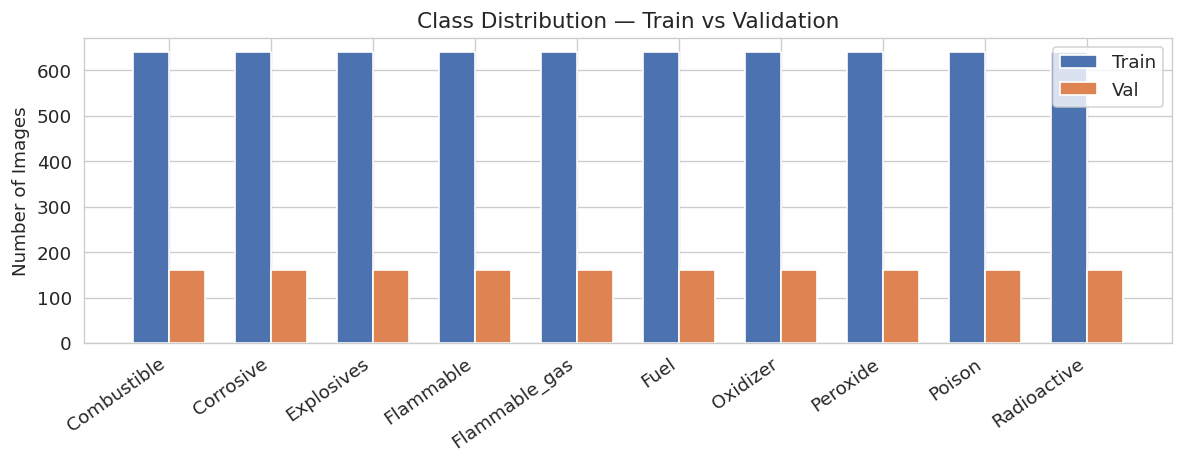

In [6]:
# ============================================================
# 3a. BAR CHART — class distribution
# ============================================================
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(df_dist))
w = 0.35
ax.bar(x - w/2, df_dist["Train"], w, label="Train", color="#4C72B0")
ax.bar(x + w/2, df_dist["Val"],   w, label="Val",   color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(df_dist["Class"], rotation=35, ha="right")
ax.set_ylabel("Number of Images")
ax.set_title("Class Distribution — Train vs Validation")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "class_distribution.png")
plt.show()

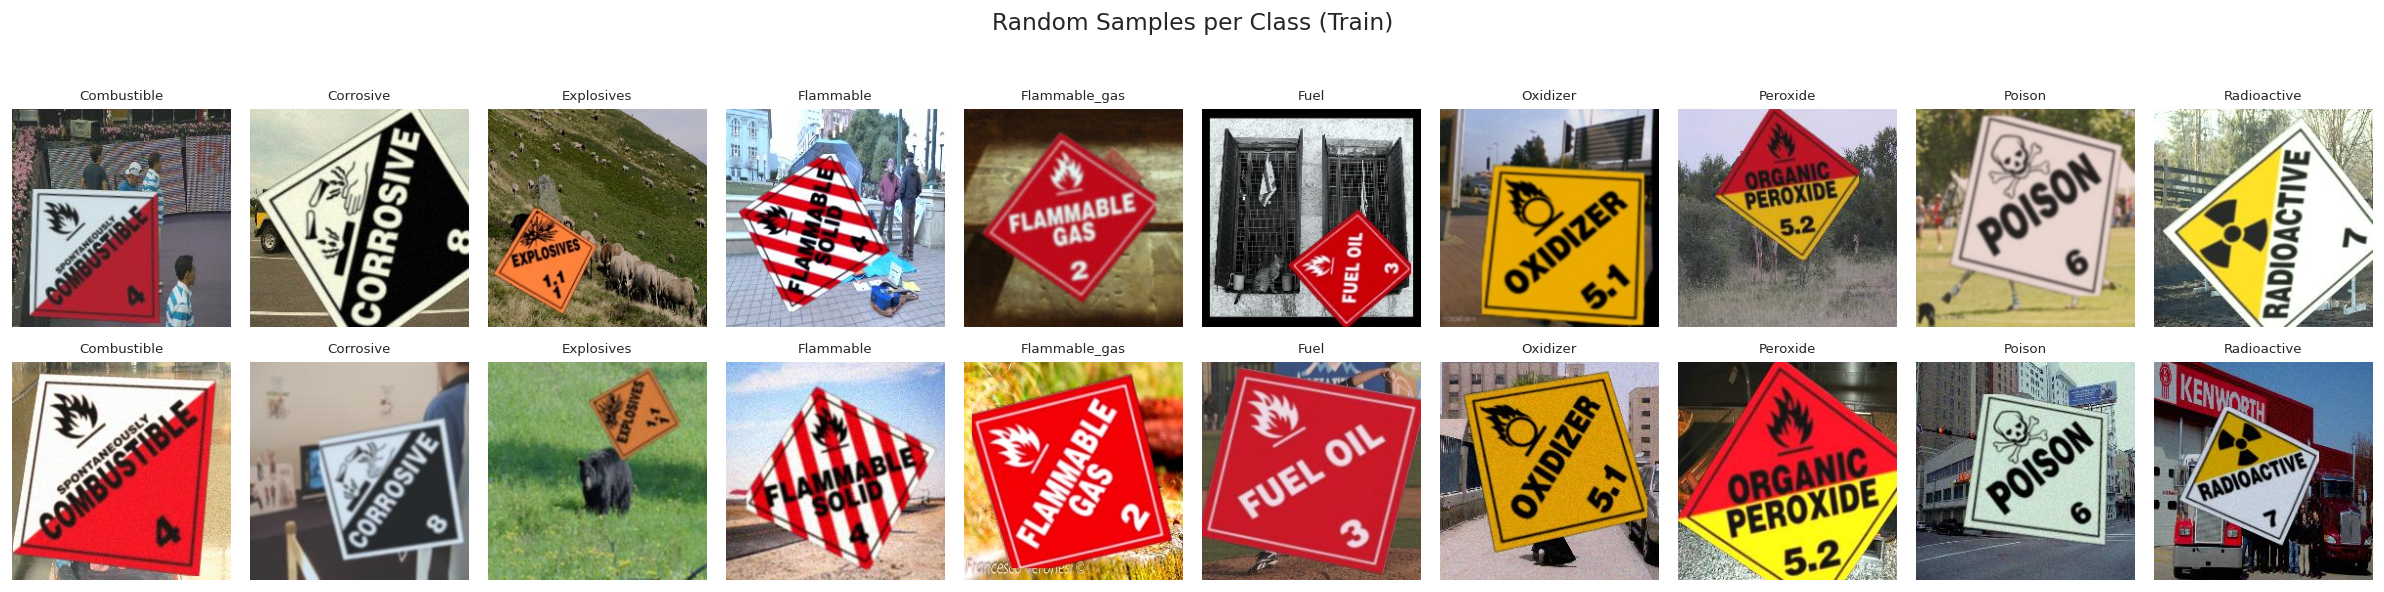

In [7]:
# ============================================================
# 3b. SAMPLE GRID — 2 random images per class
# ============================================================
fig, axes = plt.subplots(2, len(_temp_ds_train.classes), figsize=(20, 5))
class_indices = {c: [] for c in range(len(_temp_ds_train.classes))}
for idx, (_, label) in enumerate(_temp_ds_train.samples):
    class_indices[label].append(idx)

for col, cls_name in enumerate(_temp_ds_train.classes):
    samples = random.sample(class_indices[col], min(2, len(class_indices[col])))
    for row, s_idx in enumerate(samples):
        img, _ = _temp_ds_train[s_idx]
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls_name, fontsize=8)
        axes[row, col].axis("off")

plt.suptitle("Random Samples per Class (Train)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "sample_grid.png")
plt.show()

## 4. Transform Definitions (Train & Validation)

In [8]:
# ============================================================
# 4. TRANSFORMS
# ============================================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(0.85, 1.15)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Build datasets with transforms
train_dataset = datasets.ImageFolder(dataset_root / "train", transform=train_transforms)
val_dataset   = datasets.ImageFolder(dataset_root / "val",   transform=val_transforms)

print(f"  Train dataset: {len(train_dataset):,} images")
print(f"  Val   dataset: {len(val_dataset):,} images")

  Train dataset: 6,400 images
  Val   dataset: 1,600 images


## 5. Transform Visualization (Before & After)

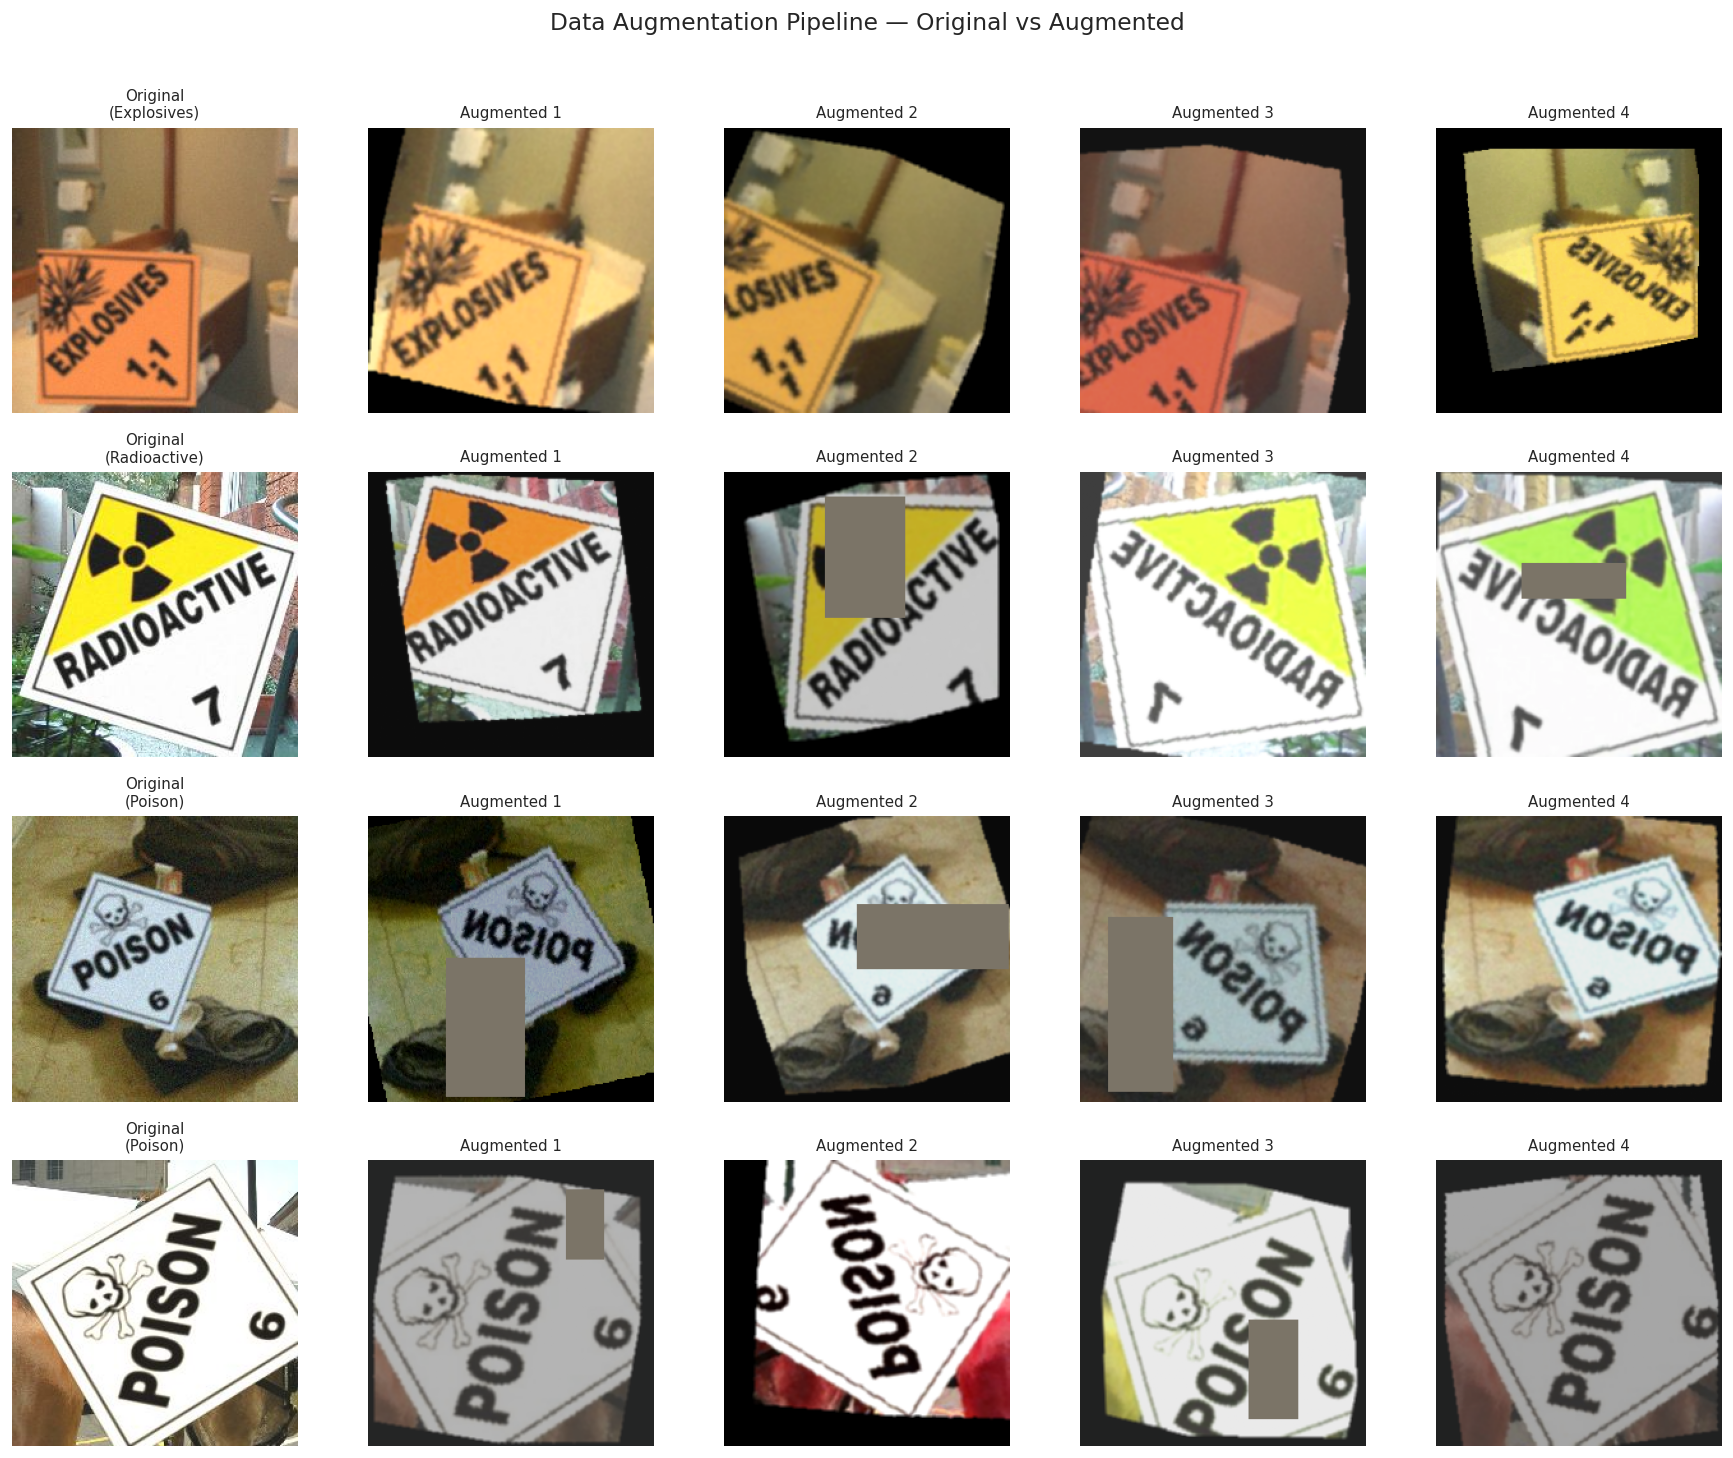

In [9]:
# ============================================================
# 5. VISUALIZE AUGMENTATIONS
# ============================================================
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Reverse ImageNet normalization for display."""
    t = tensor.clone()
    for ch, m, s in zip(t, mean, std):
        ch.mul_(s).add_(m)
    return torch.clamp(t, 0, 1)

# Pick 4 random originals (no transform)
raw_ds = datasets.ImageFolder(dataset_root / "train")
sample_indices = random.sample(range(len(raw_ds)), 4)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for row, s_idx in enumerate(sample_indices):
    orig_img, label = raw_ds[s_idx]
    cls_name = raw_ds.classes[label]

    # Original
    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title(f"Original\n({cls_name})", fontsize=9)
    axes[row, 0].axis("off")

    # 4 augmented versions
    for col in range(1, 5):
        aug_tensor = train_transforms(orig_img)
        aug_img = denormalize(aug_tensor).permute(1, 2, 0).numpy()
        axes[row, col].imshow(aug_img)
        axes[row, col].set_title(f"Augmented {col}", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Data Augmentation Pipeline — Original vs Augmented", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "augmentation_examples.png")
plt.show()

## 6. DataLoaders

In [10]:
# ============================================================
# 6. DATALOADERS
# ============================================================
pin = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset, batch_size=CONFIG["batch_size"],
    shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=pin,
)
val_loader = DataLoader(
    val_dataset, batch_size=CONFIG["batch_size"],
    shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=pin,
)

print(f"  Train batches: {len(train_loader)}")
print(f"  Val   batches: {len(val_loader)}")

# Verify shapes
imgs, labels = next(iter(train_loader))
print(f"  Batch image shape : {imgs.shape}")
print(f"  Batch label shape : {labels.shape}")
print(f"  Label range       : [{labels.min().item()}, {labels.max().item()}]")

  Train batches: 200
  Val   batches: 50
  Batch image shape : torch.Size([32, 3, 224, 224])
  Batch label shape : torch.Size([32])
  Label range       : [0, 9]


## 7. Model Definition — ResNet-18 with Custom Head

In [11]:
# ============================================================
# 7. MODEL — ResNet-18 pretrained, custom FC head
# ============================================================
model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# Replace final fully-connected layer
in_features = model.fc.in_features  # 512
model.fc = nn.Sequential(
    nn.Dropout(p=CONFIG["dropout"]),
    nn.Linear(in_features, CONFIG["num_classes"]),
)
model = model.to(DEVICE)

# Parameter counts
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("  MODEL SUMMARY")
print("=" * 60)
print(f"  Architecture     : ResNet-18")
print(f"  Pretrained       : ImageNet1K_V1")
print(f"  Custom head      : Dropout({CONFIG['dropout']}) → Linear({in_features} → {CONFIG['num_classes']})")
print(f"  Total parameters : {total_params:,}")
print(f"  Trainable params : {trainable_params:,}")
print(f"  Non-trainable    : {total_params - trainable_params:,}")
print("=" * 60)
print(f"\n  Head architecture:\n{model.fc}")

  MODEL SUMMARY
  Architecture     : ResNet-18
  Pretrained       : ImageNet1K_V1
  Custom head      : Dropout(0.3) → Linear(512 → 10)
  Total parameters : 11,181,642
  Trainable params : 11,181,642
  Non-trainable    : 0

  Head architecture:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=10, bias=True)
)


## 8. Phase 1 — Feature Extraction (Frozen Backbone)

In [12]:
# ============================================================
# 8. TRAINING UTILITIES + PHASE 1
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch; return (avg_loss, accuracy%)."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total += imgs.size(0)
    return running_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate; return (avg_loss, accuracy%)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total += imgs.size(0)
    return running_loss / total, 100.0 * correct / total


# ── History containers ──
history = {
    "train_loss": [], "train_acc": [],
    "val_loss": [],   "val_acc": [],
    "lr": [],
}
best_val_acc = 0.0
best_epoch = 0
best_model_path = OUTPUT_DIR / "models" / "best_resnet18_hazmat.pth"

# ── Freeze backbone ──
for name, param in model.named_parameters():
    if "fc" not in name:
        param.requires_grad = False

criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG["label_smoothing"])
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["phase1_lr"],
)

trainable_p1 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Phase 1 — trainable parameters: {trainable_p1:,}  (backbone FROZEN)")
print(f"  Optimizer: Adam  lr={CONFIG['phase1_lr']}")
print(f"  Loss: CrossEntropy  label_smoothing={CONFIG['label_smoothing']}")
print(f"  Epochs: {CONFIG['phase1_epochs']}\n")

t_start = time.time()

for epoch in range(1, CONFIG["phase1_epochs"] + 1):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    v_loss, v_acc = evaluate(model, val_loader, criterion, DEVICE)
    lr_now = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)
    history["lr"].append(lr_now)

    tag = ""
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_epoch = epoch
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": CONFIG["class_names"],
            "epoch": epoch,
            "val_acc": v_acc,
            "config": CONFIG,
        }, best_model_path)
        tag = "  ★ saved"

    print(f"  Epoch {epoch:02d}/{CONFIG['phase1_epochs']}  |  "
          f"Train Loss: {t_loss:.4f}  Acc: {t_acc:.2f}%  |  "
          f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.2f}%{tag}")

phase1_time = time.time() - t_start
print(f"\n  Phase 1 completed in {phase1_time:.1f}s")

  Phase 1 — trainable parameters: 5,130  (backbone FROZEN)
  Optimizer: Adam  lr=0.001
  Loss: CrossEntropy  label_smoothing=0.1
  Epochs: 5

  Epoch 01/5  |  Train Loss: 1.4857  Acc: 58.97%  |  Val Loss: 0.9430  Acc: 88.75%  ★ saved
  Epoch 02/5  |  Train Loss: 1.0669  Acc: 78.48%  |  Val Loss: 0.8391  Acc: 89.19%  ★ saved
  Epoch 03/5  |  Train Loss: 0.9914  Acc: 81.73%  |  Val Loss: 0.8054  Acc: 92.25%  ★ saved
  Epoch 04/5  |  Train Loss: 0.9662  Acc: 83.42%  |  Val Loss: 0.7809  Acc: 92.00%
  Epoch 05/5  |  Train Loss: 0.9554  Acc: 83.09%  |  Val Loss: 0.7790  Acc: 92.19%

  Phase 1 completed in 132.1s


## 9. Phase 2 — Full Fine-Tuning with Differential Learning Rate

In [13]:
# ============================================================
# 9. PHASE 2 — FULL FINE-TUNING
# ============================================================

# Unfreeze all parameters
for param in model.parameters():
    param.requires_grad = True

# Differential learning rate
backbone_params = []
head_params = []
for name, param in model.named_parameters():
    if "fc" in name:
        head_params.append(param)
    else:
        backbone_params.append(param)

optimizer = optim.Adam([
    {"params": backbone_params, "lr": CONFIG["phase2_backbone_lr"]},
    {"params": head_params,     "lr": CONFIG["phase2_head_lr"]},
], weight_decay=CONFIG["weight_decay"])

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["phase2_epochs"]
)

trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Phase 2 — trainable parameters: {trainable_p2:,}  (backbone UNFROZEN)")
print(f"  Optimizer: Adam  backbone_lr={CONFIG['phase2_backbone_lr']}  head_lr={CONFIG['phase2_head_lr']}")
print(f"  Scheduler: CosineAnnealingLR  T_max={CONFIG['phase2_epochs']}")
print(f"  Weight decay: {CONFIG['weight_decay']}")
print(f"  Epochs: {CONFIG['phase2_epochs']}\n")

t_start2 = time.time()
start_epoch = CONFIG["phase1_epochs"] + 1
end_epoch   = TOTAL_EPOCHS

for epoch in range(start_epoch, end_epoch + 1):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    v_loss, v_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()
    lr_now = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)
    history["lr"].append(lr_now)

    tag = ""
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_epoch = epoch
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": CONFIG["class_names"],
            "epoch": epoch,
            "val_acc": v_acc,
            "config": CONFIG,
        }, best_model_path)
        tag = "  ★ saved"

    print(f"  Epoch {epoch:02d}/{TOTAL_EPOCHS}  |  "
          f"Train Loss: {t_loss:.4f}  Acc: {t_acc:.2f}%  |  "
          f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.2f}%  |  "
          f"LR: {lr_now:.2e}{tag}")

phase2_time = time.time() - t_start2
total_train_time = phase1_time + phase2_time

print(f"\n  Phase 2 completed in {phase2_time:.1f}s")
print(f"  Total training time: {total_train_time:.1f}s ({total_train_time/60:.1f} min)")
print(f"  Best val accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

  Phase 2 — trainable parameters: 11,181,642  (backbone UNFROZEN)
  Optimizer: Adam  backbone_lr=0.0001  head_lr=0.001
  Scheduler: CosineAnnealingLR  T_max=25
  Weight decay: 0.0001
  Epochs: 25

  Epoch 06/30  |  Train Loss: 0.6770  Acc: 97.00%  |  Val Loss: 0.5582  Acc: 100.00%  |  LR: 9.96e-05  ★ saved
  Epoch 07/30  |  Train Loss: 0.5865  Acc: 99.30%  |  Val Loss: 0.5333  Acc: 100.00%  |  LR: 9.84e-05
  Epoch 08/30  |  Train Loss: 0.5632  Acc: 99.45%  |  Val Loss: 0.5215  Acc: 100.00%  |  LR: 9.65e-05
  Epoch 09/30  |  Train Loss: 0.5481  Acc: 99.72%  |  Val Loss: 0.5263  Acc: 100.00%  |  LR: 9.38e-05
  Epoch 10/30  |  Train Loss: 0.5412  Acc: 99.75%  |  Val Loss: 0.5131  Acc: 100.00%  |  LR: 9.05e-05
  Epoch 11/30  |  Train Loss: 0.5347  Acc: 99.73%  |  Val Loss: 0.5133  Acc: 100.00%  |  LR: 8.64e-05
  Epoch 12/30  |  Train Loss: 0.5299  Acc: 99.78%  |  Val Loss: 0.5095  Acc: 100.00%  |  LR: 8.19e-05
  Epoch 13/30  |  Train Loss: 0.5266  Acc: 99.83%  |  Val Loss: 0.5066  Acc: 100

## 10. Training Curves (Loss, Accuracy, Learning Rate)

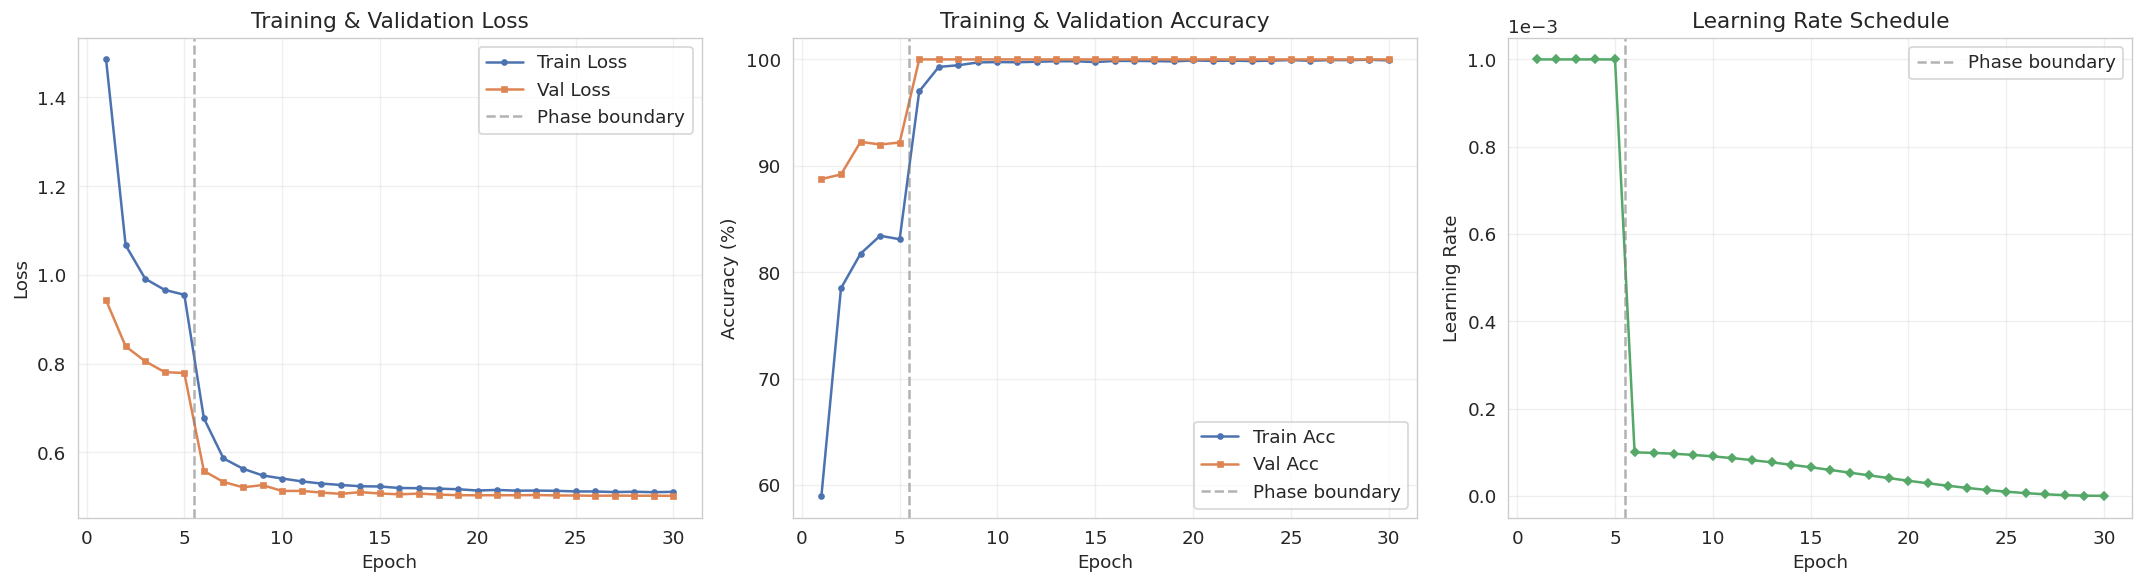

In [14]:
# ============================================================
# 10. TRAINING CURVES
# ============================================================
epochs_range = np.arange(1, TOTAL_EPOCHS + 1)
phase_boundary = CONFIG["phase1_epochs"] + 0.5  # vertical line

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Loss ──
ax = axes[0]
ax.plot(epochs_range, history["train_loss"], "o-", ms=3, label="Train Loss", color="#4C72B0")
ax.plot(epochs_range, history["val_loss"],   "s-", ms=3, label="Val Loss",   color="#DD8452")
ax.axvline(phase_boundary, ls="--", color="gray", alpha=0.6, label="Phase boundary")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Accuracy ──
ax = axes[1]
ax.plot(epochs_range, history["train_acc"], "o-", ms=3, label="Train Acc", color="#4C72B0")
ax.plot(epochs_range, history["val_acc"],   "s-", ms=3, label="Val Acc",   color="#DD8452")
ax.axvline(phase_boundary, ls="--", color="gray", alpha=0.6, label="Phase boundary")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Training & Validation Accuracy")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# ── Learning Rate ──
ax = axes[2]
ax.plot(epochs_range, history["lr"], "D-", ms=3, color="#55A868")
ax.axvline(phase_boundary, ls="--", color="gray", alpha=0.6, label="Phase boundary")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "training_curves.png")
plt.show()

## 11. Full Evaluation — Global & Per-Class Metrics

In [15]:
# ============================================================
# 11. FULL EVALUATION
# ============================================================

# Load best checkpoint
ckpt = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"  Loaded best model from epoch {ckpt['epoch']} (val acc: {ckpt['val_acc']:.2f}%)\n")

# Collect all predictions
all_labels = []
all_preds  = []
all_probs  = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

y_true  = np.array(all_labels)
y_pred  = np.array(all_preds)
y_probs = np.array(all_probs)

# Global metrics
global_acc = accuracy_score(y_true, y_pred) * 100
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
prec_wt, rec_wt, f1_wt, _         = precision_recall_fscore_support(y_true, y_pred, average="weighted")

print("=" * 60)
print("  GLOBAL METRICS")
print("=" * 60)
print(f"  Accuracy          : {global_acc:.2f}%")
print(f"  Precision (macro) : {prec_macro:.4f}")
print(f"  Recall    (macro) : {rec_macro:.4f}")
print(f"  F1-Score  (macro) : {f1_macro:.4f}")
print(f"  Precision (wt)    : {prec_wt:.4f}")
print(f"  Recall    (wt)    : {rec_wt:.4f}")
print(f"  F1-Score  (wt)    : {f1_wt:.4f}")
print("=" * 60)

# Per-class report
report = classification_report(y_true, y_pred,
                               target_names=CONFIG["class_names"],
                               output_dict=True)
df_report = pd.DataFrame(report).transpose()
print("\n")
print(df_report.to_string())

# Save to CSV
csv_path = OUTPUT_DIR / "metrics" / "classification_report.csv"
df_report.to_csv(csv_path)
print(f"\n  Classification report saved to {csv_path}")

  Loaded best model from epoch 6 (val acc: 100.00%)

  GLOBAL METRICS
  Accuracy          : 100.00%
  Precision (macro) : 1.0000
  Recall    (macro) : 1.0000
  F1-Score  (macro) : 1.0000
  Precision (wt)    : 1.0000
  Recall    (wt)    : 1.0000
  F1-Score  (wt)    : 1.0000


               precision  recall  f1-score  support
Combustible          1.0     1.0       1.0    160.0
Corrosive            1.0     1.0       1.0    160.0
Explosives           1.0     1.0       1.0    160.0
Flammable            1.0     1.0       1.0    160.0
Flammable_gas        1.0     1.0       1.0    160.0
Fuel                 1.0     1.0       1.0    160.0
Oxidizer             1.0     1.0       1.0    160.0
Peroxide             1.0     1.0       1.0    160.0
Poison               1.0     1.0       1.0    160.0
Radioactive          1.0     1.0       1.0    160.0
accuracy             1.0     1.0       1.0      1.0
macro avg            1.0     1.0       1.0   1600.0
weighted avg         1.0     1.0       1.0   160

## 12. Confusion Matrix (Absolute & Normalized)

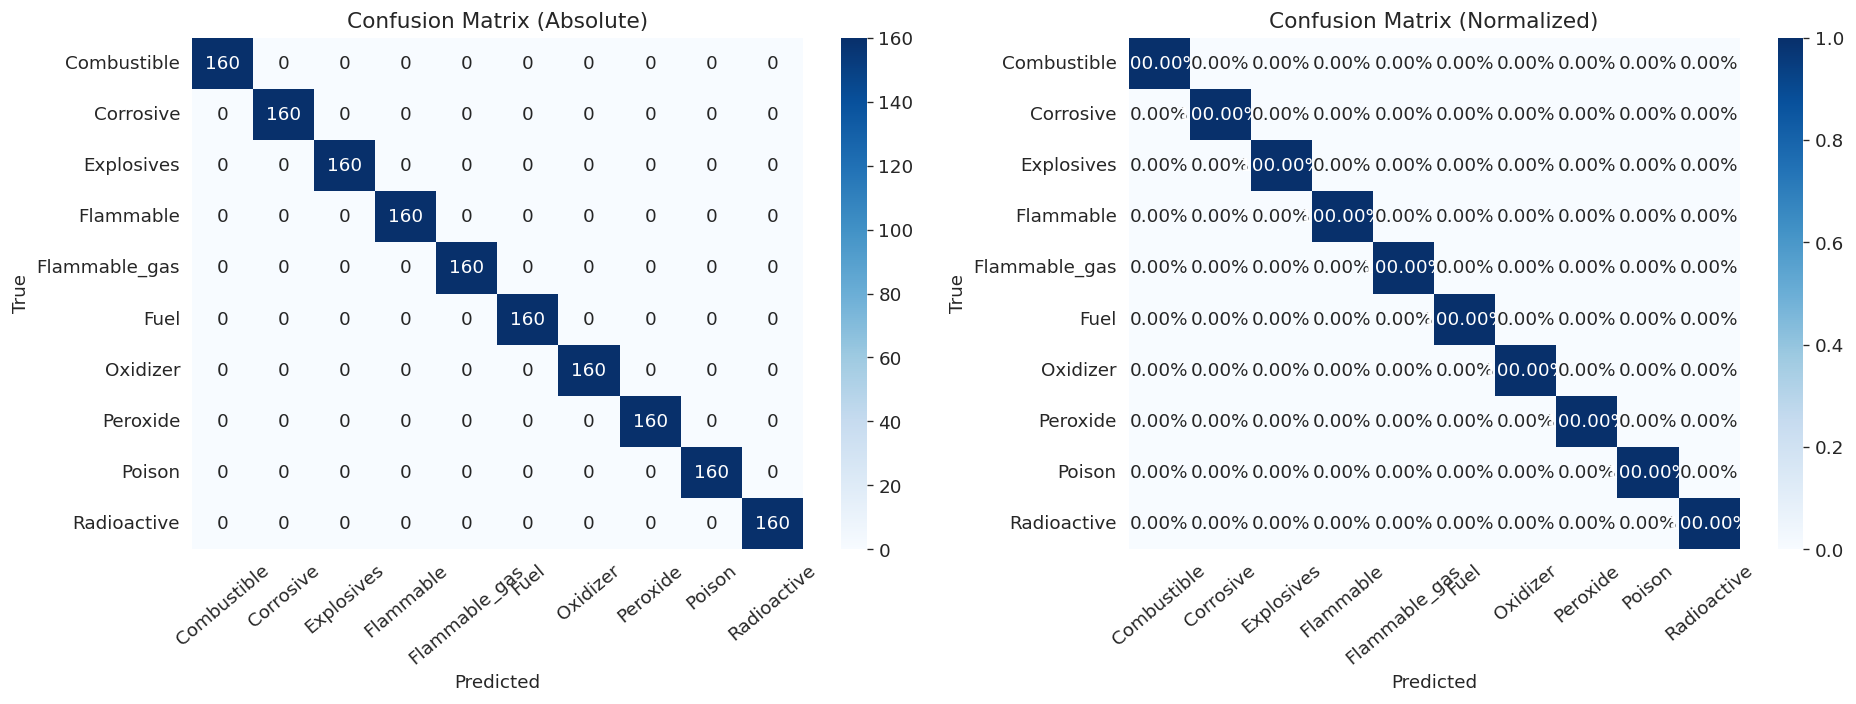

In [16]:
# ============================================================
# 12. CONFUSION MATRICES
# ============================================================
cm      = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CONFIG["class_names"],
            yticklabels=CONFIG["class_names"], ax=axes[0])
axes[0].set_title("Confusion Matrix (Absolute)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].tick_params(axis="x", rotation=40)
axes[0].tick_params(axis="y", rotation=0)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=CONFIG["class_names"],
            yticklabels=CONFIG["class_names"], ax=axes[1])
axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].tick_params(axis="x", rotation=40)
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "confusion_matrix.png")
plt.show()

## 13. Multiclass ROC Curves & AUC

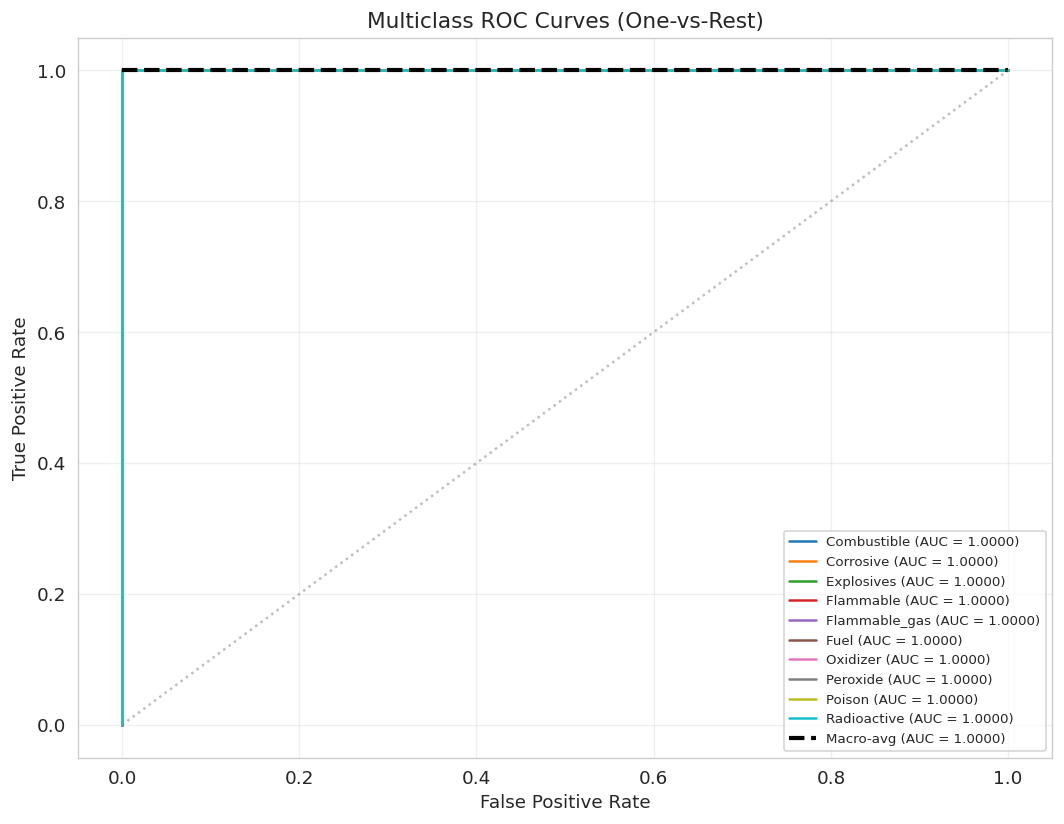


  Macro-average AUC: 1.0000


In [17]:
# ============================================================
# 13. ROC CURVES — One-vs-Rest
# ============================================================
y_true_bin = label_binarize(y_true, classes=list(range(CONFIG["num_classes"])))

fpr_dict, tpr_dict, auc_dict = {}, {}, {}
for i in range(CONFIG["num_classes"]):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr_dict[i] for i in range(CONFIG["num_classes"])]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(CONFIG["num_classes"]):
    mean_tpr += np.interp(all_fpr, fpr_dict[i], tpr_dict[i])
mean_tpr /= CONFIG["num_classes"]
macro_auc = auc(all_fpr, mean_tpr)

# Plot
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.tab10(np.linspace(0, 1, CONFIG["num_classes"]))

for i, (name, color) in enumerate(zip(CONFIG["class_names"], colors)):
    ax.plot(fpr_dict[i], tpr_dict[i], color=color, lw=1.5,
            label=f"{name} (AUC = {auc_dict[i]:.4f})")

ax.plot(all_fpr, mean_tpr, "k--", lw=2.5,
        label=f"Macro-avg (AUC = {macro_auc:.4f})")
ax.plot([0, 1], [0, 1], ":", color="gray", alpha=0.5)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Multiclass ROC Curves (One-vs-Rest)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "roc_curves.png")
plt.show()

print(f"\n  Macro-average AUC: {macro_auc:.4f}")

## 14. Model Calibration & Reliability Diagram

  Expected Calibration Error (ECE): 0.0910


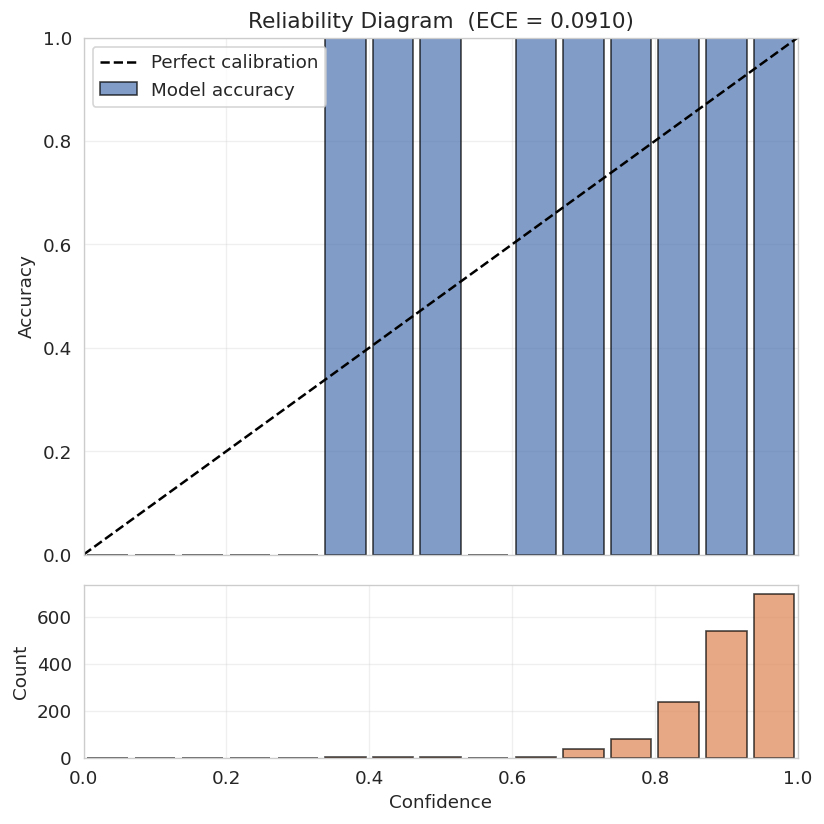

In [18]:
# ============================================================
# 14. CALIBRATION — ECE & RELIABILITY DIAGRAM
# ============================================================

def compute_ece(y_true, y_probs, n_bins=15):
    """Expected Calibration Error."""
    confidences = np.max(y_probs, axis=1)
    predictions = np.argmax(y_probs, axis=1)
    accuracies  = (predictions == y_true).astype(float)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_accs = []
    bin_confs = []
    bin_counts = []

    for b in range(n_bins):
        lo, hi = bin_boundaries[b], bin_boundaries[b + 1]
        mask = (confidences > lo) & (confidences <= hi)
        count = mask.sum()
        bin_counts.append(count)
        if count > 0:
            avg_acc  = accuracies[mask].mean()
            avg_conf = confidences[mask].mean()
            bin_accs.append(avg_acc)
            bin_confs.append(avg_conf)
            ece += (count / len(y_true)) * abs(avg_acc - avg_conf)
        else:
            bin_accs.append(0)
            bin_confs.append(0)

    return ece, bin_accs, bin_confs, bin_counts, bin_boundaries


ece_val, bin_accs, bin_confs, bin_counts, bin_edges = compute_ece(y_true, y_probs)
print(f"  Expected Calibration Error (ECE): {ece_val:.4f}")

# Reliability diagram
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7),
                                gridspec_kw={"height_ratios": [3, 1]},
                                sharex=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = 1.0 / len(bin_accs)

# Top: accuracy vs confidence
ax1.bar(bin_centers, bin_accs, width=width * 0.85, alpha=0.7,
        color="#4C72B0", edgecolor="k", label="Model accuracy")
ax1.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax1.set_ylabel("Accuracy")
ax1.set_title(f"Reliability Diagram  (ECE = {ece_val:.4f})")
ax1.legend(loc="upper left")
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

# Bottom: sample count histogram
ax2.bar(bin_centers, bin_counts, width=width * 0.85,
        color="#DD8452", edgecolor="k", alpha=0.7)
ax2.set_xlabel("Confidence")
ax2.set_ylabel("Count")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "reliability_diagram.png")
plt.show()

## 15. Grad-CAM — Activation Visualization

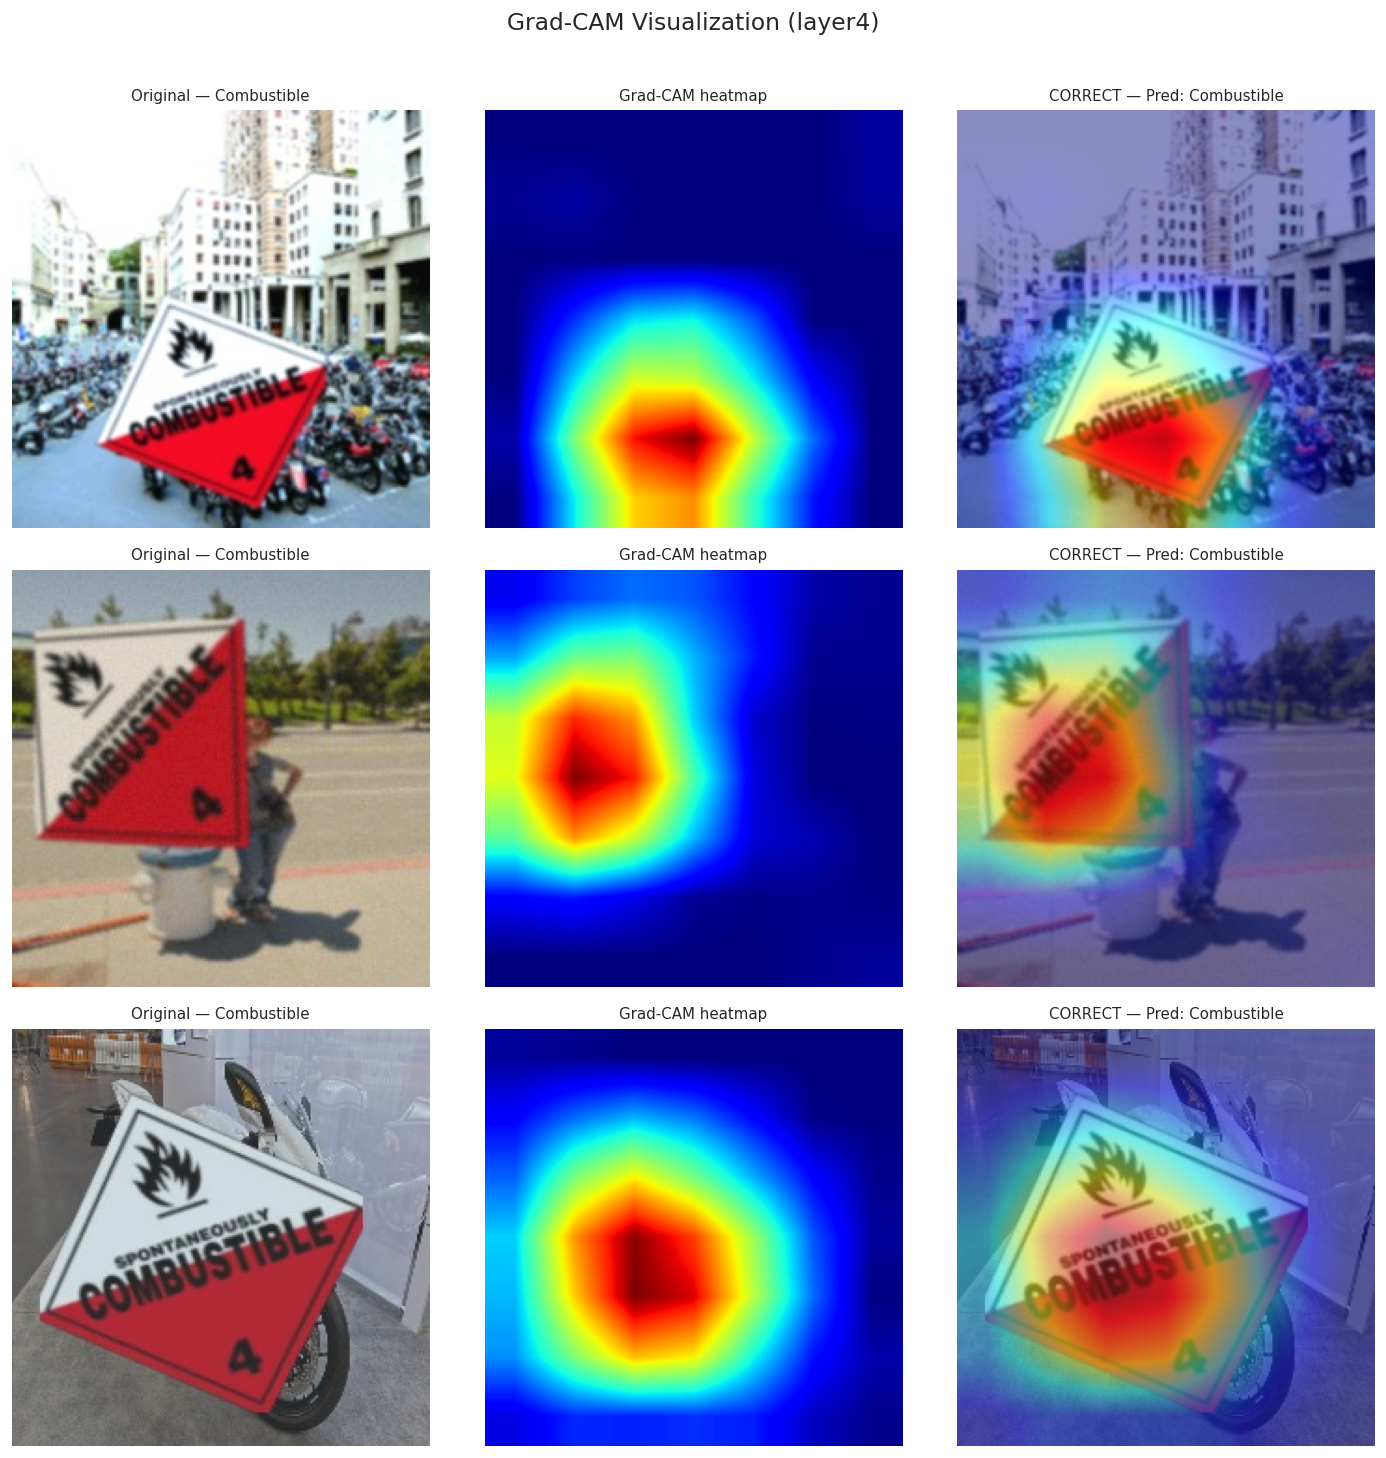

In [19]:
# ============================================================
# 15. GRAD-CAM
# ============================================================
import cv2 as cv2_local  # local alias to avoid conflicts

class GradCAM:
    """Grad-CAM for the last convolutional block of ResNet-18."""

    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        # Register hooks
        target_layer.register_forward_hook(self._fwd_hook)
        target_layer.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, module, input, output):
        self.activations = output.detach()

    def _bwd_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, target_class].backward()

        # Channel weights via global average pooling of gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # [1, C, 1, 1]
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # [1, 1, H, W]
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()

        # Normalize to [0, 1]
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam, target_class


# Initialize Grad-CAM on layer4 (last conv block)
grad_cam = GradCAM(model, model.layer4[-1])

# Find correct and incorrect predictions
correct_indices = []
incorrect_indices = []
val_raw = datasets.ImageFolder(dataset_root / "val")

for idx in range(len(val_dataset)):
    img_tensor, label = val_dataset[idx]
    with torch.no_grad():
        pred = model(img_tensor.unsqueeze(0).to(DEVICE)).argmax(1).item()
    if pred == label and len(correct_indices) < 3:
        correct_indices.append(idx)
    elif pred != label and len(incorrect_indices) < 3:
        incorrect_indices.append(idx)
    if len(correct_indices) >= 3 and len(incorrect_indices) >= 3:
        break

# If no incorrect found, just use correct ones
show_indices = correct_indices + incorrect_indices
n_show = len(show_indices)

fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
if n_show == 1:
    axes = axes[np.newaxis, :]

for row, idx in enumerate(show_indices):
    img_tensor, label = val_dataset[idx]
    raw_img, _ = val_raw[idx]
    raw_np = np.array(raw_img.resize((224, 224)))

    input_t = img_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
    cam, pred_cls = grad_cam.generate(input_t)

    # Resize CAM to image size
    cam_resized = cv2_local.resize(cam, (224, 224))
    heatmap = cv2_local.applyColorMap(np.uint8(255 * cam_resized), cv2_local.COLORMAP_JET)
    heatmap = cv2_local.cvtColor(heatmap, cv2_local.COLOR_BGR2RGB)

    overlay = (0.55 * raw_np.astype(float) + 0.45 * heatmap.astype(float))
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    is_correct = idx in correct_indices
    status = "CORRECT" if is_correct else "WRONG"
    true_name = CONFIG["class_names"][label]
    pred_name = CONFIG["class_names"][pred_cls]

    axes[row, 0].imshow(raw_np)
    axes[row, 0].set_title(f"Original — {true_name}", fontsize=9)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(cam_resized, cmap="jet")
    axes[row, 1].set_title(f"Grad-CAM heatmap", fontsize=9)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f"{status} — Pred: {pred_name}", fontsize=9)
    axes[row, 2].axis("off")

plt.suptitle("Grad-CAM Visualization (layer4)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "gradcam.png")
plt.show()

## 16. Robustness Evaluation Under Perturbations

             Condition  Accuracy (%)  Drop (pp)
      Baseline (clean)        100.00       0.00
Heavy Blur (k=11, σ=5)         95.06       4.94
  Heavy Noise (σ=0.15)        100.00       0.00
      Extreme Lighting         91.62       8.38


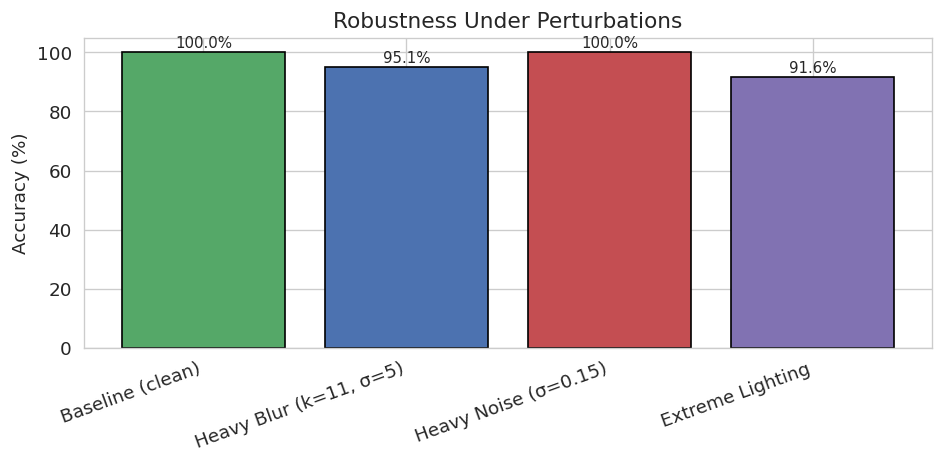

In [20]:
# ============================================================
# 16. ROBUSTNESS EVALUATION
# ============================================================

class AddGaussianNoise:
    """Custom transform: adds Gaussian noise to a tensor."""
    def __init__(self, std=0.15):
        self.std = std
    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std
    def __repr__(self):
        return f"AddGaussianNoise(std={self.std})"


perturbations = {
    "Baseline (clean)": val_transforms,
    "Heavy Blur (k=11, σ=5)": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.GaussianBlur(kernel_size=11, sigma=5.0),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
    "Heavy Noise (σ=0.15)": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        AddGaussianNoise(std=0.15),
    ]),
    "Extreme Lighting": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ColorJitter(brightness=1.5, contrast=1.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]),
}

robustness_results = []
baseline_acc = None

model.eval()
for name, tfm in perturbations.items():
    ds = datasets.ImageFolder(dataset_root / "val", transform=tfm)
    loader = DataLoader(ds, batch_size=CONFIG["batch_size"],
                        shuffle=False, num_workers=CONFIG["num_workers"])
    _, acc = evaluate(model, loader, criterion, DEVICE)

    if baseline_acc is None:
        baseline_acc = acc
    drop = baseline_acc - acc

    robustness_results.append({
        "Condition": name,
        "Accuracy (%)": round(acc, 2),
        "Drop (pp)": round(drop, 2),
    })

df_robust = pd.DataFrame(robustness_results)
print(df_robust.to_string(index=False))

# Save
df_robust.to_csv(OUTPUT_DIR / "metrics" / "robustness.csv", index=False)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ["#55A868", "#4C72B0", "#C44E52", "#8172B2"]
ax.bar(df_robust["Condition"], df_robust["Accuracy (%)"], color=colors_bar, edgecolor="k")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Robustness Under Perturbations")
ax.set_ylim(0, 105)
for i, v in enumerate(df_robust["Accuracy (%)"]):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "plots" / "robustness.png")
plt.show()

## 17. Data Leakage Analysis

In [21]:
# ============================================================
# 17. DATA LEAKAGE ANALYSIS
# ============================================================

def file_md5(path, chunk=8192):
    """Compute MD5 hash of a file."""
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            data = f.read(chunk)
            if not data:
                break
            h.update(data)
    return h.hexdigest()


# ── 17a. Exact duplicate detection via MD5 ──
print("  Computing MD5 hashes for all images...")
train_hashes = {}
for path, _ in _temp_ds_train.samples:
    h = file_md5(path)
    train_hashes[h] = path

val_hashes = {}
for path, _ in _temp_ds_val.samples:
    h = file_md5(path)
    val_hashes[h] = path

duplicates = set(train_hashes.keys()) & set(val_hashes.keys())
print(f"  Train unique images : {len(train_hashes)}")
print(f"  Val   unique images : {len(val_hashes)}")
print(f"  Exact duplicates between train/val: {len(duplicates)}")
if len(duplicates) > 0:
    print("  ⚠  WARNING: Duplicate images detected between splits!")
    for h in list(duplicates)[:5]:
        print(f"    Train: {train_hashes[h]}")
        print(f"    Val  : {val_hashes[h]}")
else:
    print("  ✓ No exact duplicates found — no data leakage from identical files.")

# ── 17b. Perceptual similarity via embeddings ──
print("\n  Computing perceptual similarity via model embeddings...")

# Extract embeddings (output of avgpool, before FC)
def get_embeddings(model, loader, device, max_samples=200):
    """Extract avgpool embeddings from the model."""
    model.eval()
    embeddings = []
    hook_output = []

    def hook_fn(module, inp, out):
        hook_output.append(out.detach())

    handle = model.avgpool.register_forward_hook(hook_fn)
    count = 0
    with torch.no_grad():
        for imgs, _ in loader:
            if count >= max_samples:
                break
            imgs = imgs.to(device)
            _ = model(imgs)
            emb = hook_output[-1].squeeze(-1).squeeze(-1)  # [B, 512]
            embeddings.append(emb.cpu())
            count += imgs.size(0)
            hook_output.clear()
    handle.remove()
    return torch.cat(embeddings, dim=0)[:max_samples]

train_emb = get_embeddings(model, train_loader, DEVICE, max_samples=200)
val_emb   = get_embeddings(model, val_loader, DEVICE, max_samples=200)

# Normalize for cosine similarity
train_emb_n = torch.nn.functional.normalize(train_emb, dim=1)
val_emb_n   = torch.nn.functional.normalize(val_emb, dim=1)

# Cross-split similarity
cross_sim = (train_emb_n @ val_emb_n.T).mean().item()
# Within-train similarity
train_sim = (train_emb_n @ train_emb_n.T).fill_diagonal_(0).sum() / (len(train_emb_n) * (len(train_emb_n) - 1))
train_sim = train_sim.item()
# Within-val similarity
val_sim = (val_emb_n @ val_emb_n.T).fill_diagonal_(0).sum() / (len(val_emb_n) * (len(val_emb_n) - 1))
val_sim = val_sim.item()

leakage_df = pd.DataFrame([
    {"Comparison": "Within Train", "Mean Cosine Similarity": f"{train_sim:.4f}"},
    {"Comparison": "Within Val",   "Mean Cosine Similarity": f"{val_sim:.4f}"},
    {"Comparison": "Cross (Train↔Val)", "Mean Cosine Similarity": f"{cross_sim:.4f}"},
])
print(leakage_df.to_string(index=False))

if cross_sim > 0.95 * max(train_sim, val_sim):
    print("\n  ⚠  Cross-split similarity is very close to within-split — possible leakage risk.")
else:
    print("\n  ✓ Cross-split similarity is lower than within-split — no significant leakage detected.")

  Computing MD5 hashes for all images...
  Train unique images : 6400
  Val   unique images : 1600
  Exact duplicates between train/val: 0
  ✓ No exact duplicates found — no data leakage from identical files.

  Computing perceptual similarity via model embeddings...
       Comparison Mean Cosine Similarity
     Within Train                 0.6277
       Within Val                 0.7481
Cross (Train↔Val)                 0.6288

  ✓ Cross-split similarity is lower than within-split — no significant leakage detected.


## 18. Export Results (Model, CSV, PNG, JSON)

In [22]:
# ============================================================
# 18. EXPORT ALL RESULTS
# ============================================================
from datetime import datetime

# ── JSON report ──
experiment_report = {
    "experiment_name": CONFIG["experiment_name"],
    "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model": "ResNet-18 (ImageNet1K_V1)",
    "num_classes": CONFIG["num_classes"],
    "class_names": CONFIG["class_names"],
    "dataset_dir": CONFIG["dataset_dir"],
    "train_samples": len(train_dataset),
    "val_samples": len(val_dataset),
    "total_epochs": TOTAL_EPOCHS,
    "best_epoch": best_epoch,
    "best_val_accuracy": round(best_val_acc, 4),
    "global_accuracy": round(global_acc, 4),
    "precision_macro": round(prec_macro, 4),
    "recall_macro": round(rec_macro, 4),
    "f1_macro": round(f1_macro, 4),
    "auc_macro": round(macro_auc, 4),
    "ece": round(ece_val, 4),
    "total_parameters": total_params,
    "trainable_parameters": trainable_p2,
    "training_time_seconds": round(total_train_time, 1),
    "device": str(DEVICE),
    "seed": SEED,
    "phase1": {
        "epochs": CONFIG["phase1_epochs"],
        "lr": CONFIG["phase1_lr"],
        "strategy": "Frozen backbone (feature extraction)",
    },
    "phase2": {
        "epochs": CONFIG["phase2_epochs"],
        "backbone_lr": CONFIG["phase2_backbone_lr"],
        "head_lr": CONFIG["phase2_head_lr"],
        "weight_decay": CONFIG["weight_decay"],
        "scheduler": "CosineAnnealingLR",
        "strategy": "Full fine-tuning with differential LR",
    },
}

report_path = OUTPUT_DIR / "experiment_report.json"
with open(report_path, "w") as f:
    json.dump(experiment_report, f, indent=2)

# ── List all exported files ──
print("=" * 60)
print("  EXPORTED FILES")
print("=" * 60)
for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(str(OUTPUT_DIR), "").count(os.sep)
    indent = "  " + "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = "  " + "  " * (level + 1)
    for file in sorted(files):
        fpath = Path(root) / file
        size_kb = fpath.stat().st_size / 1024
        print(f"{sub_indent}{file}  ({size_kb:.1f} KB)")
print("=" * 60)

  EXPORTED FILES
  experiment_results/
    experiment_report.json  (1.1 KB)
    metrics/
      classification_report.csv  (0.4 KB)
      robustness.csv  (0.2 KB)
    plots/
      augmentation_examples.png  (2769.1 KB)
      class_distribution.png  (78.5 KB)
      confusion_matrix.png  (186.3 KB)
      gradcam.png  (2141.2 KB)
      reliability_diagram.png  (64.6 KB)
      robustness.png  (63.9 KB)
      roc_curves.png  (98.0 KB)
      sample_grid.png  (2701.0 KB)
      training_curves.png  (128.0 KB)
    models/
      best_resnet18_hazmat.pth  (43758.1 KB)


## 19. Final Experiment Summary

In [23]:
# ============================================================
# 19. FINAL EXPERIMENT SUMMARY
# ============================================================
mins = int(total_train_time // 60)
secs = int(total_train_time % 60)

print()
print("╔" + "═" * 58 + "╗")
print("║" + "  EXPERIMENT SUMMARY".center(58) + "║")
print("╠" + "═" * 58 + "╣")
print(f"║  Experiment       : {CONFIG['experiment_name']:<36} ║")
print(f"║  Date             : {datetime.now().strftime('%Y-%m-%d %H:%M'):<36} ║")
print("╠" + "═" * 58 + "╣")
print(f"║  Final Accuracy   : {best_val_acc:>8.2f}%{' ' * 27}║")
print(f"║  Best Epoch       : {best_epoch:>8d}{' ' * 27}║")
print(f"║  AUC (macro)      : {macro_auc:>8.4f}{' ' * 27}║")
print(f"║  ECE              : {ece_val:>8.4f}{' ' * 27}║")
print("╠" + "═" * 58 + "╣")
print(f"║  Training Time    : {mins}m {secs}s{' ' * (32 - len(f'{mins}m {secs}s'))}║")
print(f"║  Total Parameters : {total_params:>12,}{' ' * 23}║")
print(f"║  Trainable Params : {trainable_p2:>12,}{' ' * 23}║")
print(f"║  Device           : {str(DEVICE):<36} ║")
print("╠" + "═" * 58 + "╣")
print("║  Exported Files:".ljust(59) + "║")
print(f"║    Model  : {str(best_model_path):<44} ║")
print(f"║    Report : {str(report_path):<44} ║")
print(f"║    Metrics: {str(OUTPUT_DIR / 'metrics/'):<44} ║")
print(f"║    Plots  : {str(OUTPUT_DIR / 'plots/'):<44} ║")
print("╚" + "═" * 58 + "╝")
print("\n  Experiment complete. All results saved.")


╔══════════════════════════════════════════════════════════╗
║                     EXPERIMENT SUMMARY                   ║
╠══════════════════════════════════════════════════════════╣
║  Experiment       : Hazmat_ResNet18_TransferLearning     ║
║  Date             : 2026-02-13 17:49                     ║
╠══════════════════════════════════════════════════════════╣
║  Final Accuracy   :   100.00%                           ║
║  Best Epoch       :        6                           ║
║  AUC (macro)      :   1.0000                           ║
║  ECE              :   0.0910                           ║
╠══════════════════════════════════════════════════════════╣
║  Training Time    : 13m 3s                          ║
║  Total Parameters :   11,181,642                       ║
║  Trainable Params :   11,181,642                       ║
║  Device           : cuda                                 ║
╠══════════════════════════════════════════════════════════╣
║  Exported Files:                     